#### 분석 목표 : Olist의 성장은 왜 리텐션이 아니라 고가치 고객 유입에 달려 있는가?

## 분석 단계: LTV 기반 성장 구조 검증

### 목적
- 리텐션/재구매 분석 결과를 바탕으로
  Olist 서비스의 성장이
  ‘고객 유지’가 아닌 ‘고가치 고객 분포’에 의해 결정되는지 검증한다.

### 배경 요약
- 전체 고객 중 약 3%만 재구매
- 재구매는 대부분 첫 30일 이내 발생
- 장기 리텐션 개선의 효과는 제한적

### 분석 질문
1. 고객 매출 분포는 파레토 구조를 띠는가?
2. 성장 전략의 초점은 어디에 두어야 하는가?

In [99]:
import pandas as pd

# 베이스 테이블 로드
orders = pd.read_csv(
    '../data/processed/orders_base_delivered.csv',
    parse_dates=['order_purchase_timestamp']
)

#orders_base_delivered 테이블은 다음을 보장한다:
#배송 완료 주문만 포함
#customer_id 기준 분석 가능
#payment_value 기준 매출 분석 가능

orders.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,payment_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-10 21:25:13,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-08-07 15:27:45,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-17 18:06:29,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-12-02 00:28:42,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-16 18:17:02,28.62,2018-02


In [100]:
# 고객별 누적 매출(LTV) 계산 (진짜 고객 기준)
customer_ltv = (
    orders
    .groupby("customer_unique_id", as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "ltv"})
)

customer_ltv.describe()

,ltv
count,93357.000000
mean,165.198772
std,226.314579
min,9.590000
25%,63.060000
50%,107.780000
75%,182.560000
max,13664.080000


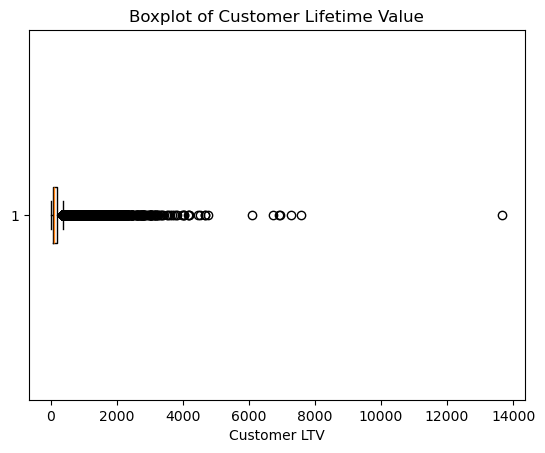

In [101]:
import matplotlib.pyplot as plt

# 고객별 누적 매출(LTV) 시리즈
ltv_series = customer_ltv['ltv']

# 1️⃣ 박스플롯: LTV 분포 요약 및 이상치 확인
plt.figure()
plt.boxplot(ltv_series, vert=False)
plt.xlabel('Customer LTV')
plt.title('Boxplot of Customer Lifetime Value')
plt.show()

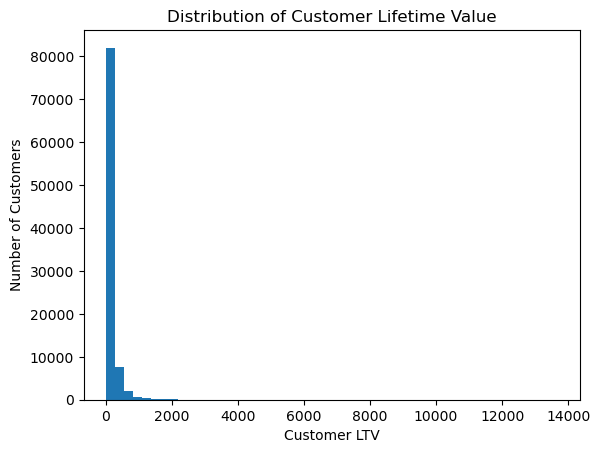

In [102]:
# 2️⃣ 분포 히스토그램: 고객 LTV 분포 형태 확인
plt.figure()
plt.hist(ltv_series, bins=50)
plt.xlabel('Customer LTV')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Lifetime Value')
plt.show()

## 고객별 LTV 분포 결과 해석

고객별 누적 매출(LTV) 분포를 확인한 결과, Olist 서비스의 매출은
소수 고객에게 강하게 집중된 비대칭 구조를 보임

전체 고객의 중앙값 LTV는 약 105로,
절반 이상의 고객이 본 수준 이하 매출 발생
반면 평균 LTV는 약 160으로 중앙값보다 크게 높아,
극소수 고액 고객이 전체 평균을 끌어올리고 있음을 시사함

또한 고객의 75%가 누적 매출 176 이하에 머무르는 반면,
최대 LTV는 13,000 이상으로 관측되어
일부 초고가치 고객이 존재하는 극단적인 우측 꼬리 분포(right-skewed distribution)가 확인

이는 Olist 서비스의 성장이
‘평균적인 다수 고객’이 아닌,
‘소수의 고가치 고객’에 의해 좌우되는 구조임을 의미

## 고객별 LTV 분포 시각화 결과 해석

박스플롯과 분포 히스토그램을 통해 고객별 누적 매출(LTV)의 분포 형태를 시각적으로 확인한 결과,
Olist 서비스의 매출 구조는 극단적으로 우측으로 치우친(right-skewed) 형태를 보인다.

박스플롯 기준으로 중앙값과 사분위 범위는 매우 좁은 구간에 밀집되어 있으며,
대부분의 고객이 낮은 LTV 구간에 집중되어 있음을 확인할 수 있다.
반면, 박스플롯 오른쪽에는 다수의 이상치(outlier)가 길게 분포하고 있어
소수 고객이 매우 큰 누적 매출을 발생시키고 있음을 시사한다.

히스토그램에서도 전체 고객의 대다수가 낮은 LTV 구간에 몰려 있고,
고LTV 구간으로 갈수록 고객 수는 급격히 감소하는 패턴이 관측된다.
이는 평균적인 고객 행동보다,
극소수 고가치 고객의 존재가 전체 매출 규모에 큰 영향을 미치는 구조임을 의미한다.

종합하면, Olist의 고객 매출 분포는
‘다수의 저가치 고객 + 소수의 초고가치 고객’로 구성된 전형적인 파레토 분포 특성을 가지며,
서비스 성장을 논의할 때 평균 고객이 아닌
고가치 고객 집단에 초점을 맞춰야 할 필요성을 강하게 뒷받침한다.

----
## STEP 3. 고객 매출의 파레토 구조 정량화

### 분석 단계 목적
- 고객 매출(LTV)이 파레토 구조를 가지는지 정량적으로 확인한다.
- 상위 소수 고객(Top 1%, 5%, 10%, 20%)이
  전체 매출의 얼마를 차지하는지 수치로 고정한다.
- 이후 고가치 고객 정의 및 성장 전략 논의의 기준선을 마련한다.

### 확인하려는 항목
- 누적 고객 비율 대비 누적 매출 비율 (Pareto Curve)
- Top 1 / 5 / 10 / 20% 고객의 매출 기여도
- 각 구간별 고가치 고객 LTV 경계값

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# STEP 3-1. 고객별 LTV 기준 내림차순 정렬
# 파레토 분석을 위해 고매출 고객부터 누적 계산
customer_ltv_sorted = customer_ltv.sort_values('ltv', ascending=False)

# STEP 3-2. 누적 매출 비율 계산
#  cumsum(): 누적합 계산
#  전체 매출로 나누어 누적 매출 비율로 변환
customer_ltv_sorted['cum_revenue_ratio'] = (
    customer_ltv_sorted['ltv'].cumsum()
    / customer_ltv_sorted['ltv'].sum()
)

# STEP 3-3. 누적 고객 비율 계산
#  np.arange(): 1부터 고객 수까지의 숫자 배열 생성
#  전체 고객 수로 나누어 누적 고객 비율로 변환
customer_ltv_sorted['cum_customer_ratio'] = (
    np.arange(1, len(customer_ltv_sorted) + 1)
    / len(customer_ltv_sorted)
)

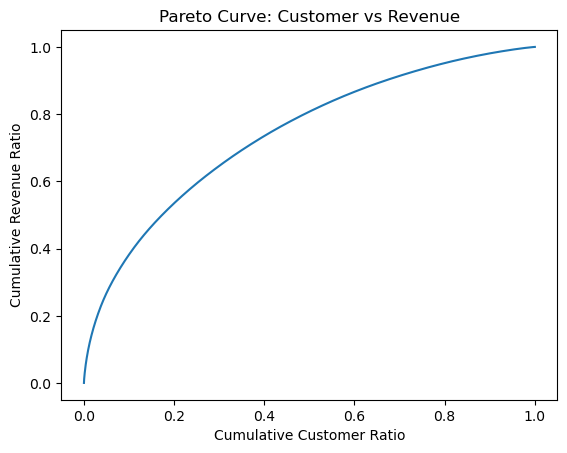

In [104]:
# STEP 3-4. 파레토 곡선 시각화
# - x축: 누적 고객 비율
# - y축: 누적 매출 비율

plt.figure()
plt.plot(
    customer_ltv_sorted['cum_customer_ratio'],
    customer_ltv_sorted['cum_revenue_ratio']
)
plt.xlabel('Cumulative Customer Ratio')
plt.ylabel('Cumulative Revenue Ratio')
plt.title('Pareto Curve: Customer vs Revenue')
plt.show()

## 파레토 커브의 축 해석

- x축 (Cumulative Customer Ratio)
  : 매출이 큰 고객부터 누적했을 때의 고객 비율
- y축 (Cumulative Revenue Ratio)
  : 해당 고객들이 만들어낸 누적 매출 비율

## 파레토 커브가 말해주는 구조적 정보

파레토 커브가 초반에 급격히 상승한다는 것은,
소수의 고객만으로도 전체 매출의 상당 부분이 만들어진다는 의미다.

반대로 곡선이 완만해질수록,  추가로 고객을 포함해도 매출 증가 폭은 점점 작아진다.

## 본 분석 결과에서의 파레토 커브 해석

Olist의 파레토 커브는 초기 구간에서 매우 가파르게 상승하며,
상위 소수 고객이 전체 매출의 큰 비중을 빠르게 형성하고 있음을 보여준다.

이는 매출이 고객 전체에 고르게 분포된 구조가 아니라,
극소수의 고가치 고객에 의해 주도되는 구조임을 의미한다.
따라서 서비스 성장의 핵심 레버는
전체 고객 수의 증가나 장기 리텐션이 아니라,
고가치 고객의 확보와 확대에 있다.

In [105]:
# STEP 3-5. Top 고객 구간별 매출 기여도 및 LTV 경계값 계산
# - quantile(): 상위 고객 컷(LTV 기준) 산출
# - 해당 컷 이하 고객을 제외한 매출 비중 계산

for p in [0.01, 0.05, 0.10, 0.20]:
    cutoff = customer_ltv_sorted['ltv'].quantile(1 - p)
    revenue_share = (
        customer_ltv_sorted
        .query('ltv >= @cutoff')['ltv']
        .sum()
        / customer_ltv_sorted['ltv'].sum()
    )
    
    print(f"Top {int(p*100)}% 고객")
    print(f" - LTV 경계값: {cutoff:.2f}")
    print(f" - 매출 비중: {revenue_share:.2%}")
    print('-' * 30)

Top 1% 고객
 - LTV 경계값: 1097.06
 - 매출 비중: 10.35%
------------------------------
Top 5% 고객
 - LTV 경계값: 469.62
 - 매출 비중: 26.80%
------------------------------
Top 10% 고객
 - LTV 경계값: 318.08
 - 매출 비중: 38.25%
------------------------------
Top 20% 고객
 - LTV 경계값: 208.55
 - 매출 비중: 53.53%
------------------------------


## 본 분석 결과에서의 파레토 구조 해석

Olist 고객 매출(LTV) 분석 결과,
고객 매출은 전형적인 파레토 구조를 보인다.

- 상위 1% 고객이 전체 매출의 약 10%
- 상위 5% 고객이 약 27%
- 상위 10% 고객이 약 38%
- 상위 20% 고객이 절반 이상(약 53%)의 매출을 차지한다

이는 매출이 다수의 평균적인 고객이 아니라,
소수의 고가치 고객에 의해 주도되고 있음을 의미한다.

따라서 Olist 서비스의 성장은
‘전체 고객을 조금씩 개선하는 문제’라기보다,
‘고가치 고객 집단의 확보와 확대’에 의해 결정되는 구조라고 해석할 수 있다.

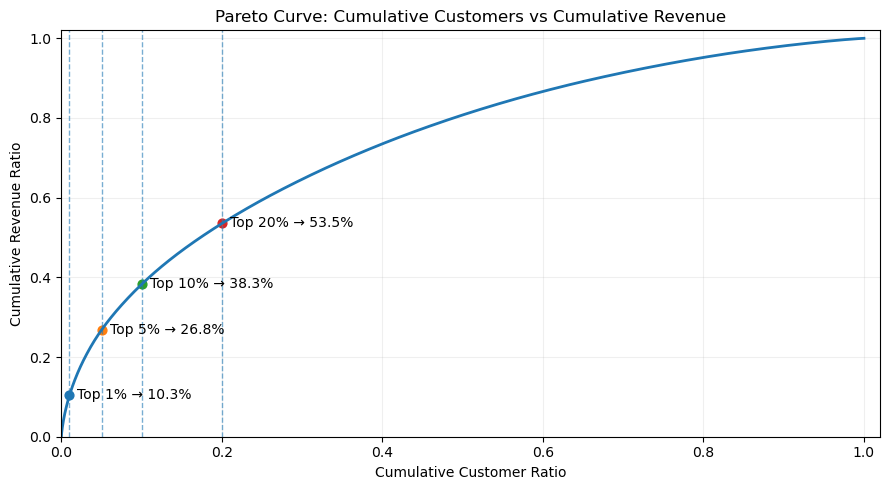

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# STEP 1) 고객 LTV 내림차순 정렬 (진짜 고객 기준)
df = customer_ltv[['customer_unique_id', 'ltv']].dropna().copy()
df = df.sort_values('ltv', ascending=False).reset_index(drop=True)

# STEP 2) 누적 비율 계산
df['cum_revenue_ratio'] = df['ltv'].cumsum() / df['ltv'].sum()
df['cum_customer_ratio'] = (np.arange(1, len(df) + 1)) / len(df)

# STEP 3) 파레토 커브 시각화
plt.figure(figsize=(9, 5))
plt.plot(df['cum_customer_ratio'], df['cum_revenue_ratio'], linewidth=2)

plt.title('Pareto Curve: Cumulative Customers vs Cumulative Revenue')
plt.xlabel('Cumulative Customer Ratio')
plt.ylabel('Cumulative Revenue Ratio')
plt.ylim(0, 1.02)
plt.xlim(0, 1.02)

# STEP 4) Top 구간 강조
top_points = [0.01, 0.05, 0.10, 0.20]

for p in top_points:
    idx = (df['cum_customer_ratio'] - p).abs().idxmin()
    x = df.loc[idx, 'cum_customer_ratio']
    y = df.loc[idx, 'cum_revenue_ratio']
    
    plt.axvline(x=x, linestyle='--', linewidth=1, alpha=0.6)
    plt.scatter([x], [y], s=40)
    plt.text(
        x + 0.01, y,
        f'Top {int(p*100)}% → {y*100:.1f}%',
        va='center'
    )

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## STEP 4. 고가치 고객의 유입 시점 및 초기 특성 탐색

### 분석 단계 목적
- 파레토 분석에서 정의한 고가치 고객(Top 5%)이
  일반 고객과 비교했을 때,
  **처음 유입 시점부터 다른 특성을 보이는지**를 확인한다.
- 고가치 고객을 사후적으로 구분하는 것이 아니라,
  **획득 단계(Acquisition)에서 식별 가능한 신호가 있는지**를 탐색한다.

### 분석 질문
2. 첫 구매 카테고리에서 일반 고객과 차이가 존재하는가?
3. “고가치 고객은 처음부터 다른가?”에 대한 정량적 근거를 확보할 수 있는가?

### 비교 대상 정의
- High Value 고객: LTV 상위 5%
- Normal 고객: 그 외 전체 고객

In [107]:

#first_orders 생성 
import pandas as pd

# 0) orders: 02에서 만든 기준 테이블을 읽어온 상태라고 가정
# orders columns should include: customer_unique_id, order_id, order_purchase_timestamp

# 1) 고객별 첫 구매 주문(order_id) 뽑기
first_orders = (
    orders.sort_values("order_purchase_timestamp")
    .groupby("customer_unique_id", as_index=False)
    .first()[["customer_unique_id", "order_id", "order_purchase_timestamp"]]
)

first_orders.head()

,customer_unique_id,order_id,order_purchase_timestamp
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42


In [108]:
"segment" in first_orders.columns

False

In [109]:
# LTV 상위 5% 기준값
ltv_cutoff = customer_ltv["ltv"].quantile(0.95)

# High Value Customer 플래그
customer_ltv["high_value"] = customer_ltv["ltv"] >= ltv_cutoff

customer_ltv["high_value"].value_counts()

high_value
False    88689
True      4668
Name: count, dtype: int64

In [110]:
print(first_orders.columns)
print(customer_ltv.columns)


Index(['customer_unique_id', 'order_id', 'order_purchase_timestamp'], dtype='object')
Index(['customer_unique_id', 'ltv', 'high_value'], dtype='object')


In [111]:
import pandas as pd

base_path = "../data/raw/"

items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
products = pd.read_csv(base_path + "olist_products_dataset.csv")[["product_id", "product_category_name"]]

In [112]:
first_item_per_order = (
    items.sort_values(["order_id", "order_item_id"])      # order_item_id = 1,2,3...
    .drop_duplicates(subset=["order_id"], keep="first")   # 주문당 1개 대표 상품
    [["order_id", "product_id"]]
)

In [113]:
first_orders = (
    first_orders
    .merge(first_item_per_order, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
)

first_orders[["order_id", "product_id", "product_category_name"]].head()

,order_id,product_id,product_category_name
0,e22acc9c116caa3f2b7121bbb380d08e,372645c7439f9661fbbacfd129aa92ec,cama_mesa_banho
1,3594e05a005ac4d06a72673270ef9ec9,5099f7000472b634fea8304448d20825,beleza_saude
2,b33ec3b699337181488304f362a6b734,64b488de448a5324c4134ea39c28a34b,papelaria
3,41272756ecddd9a9ed0180413cc22fb6,2345a354a6f2033609bbf62bf5be9ef6,telefonia
4,d957021f1127559cd947b62533f484f7,c72e18b3fe2739b8d24ebf3102450f37,telefonia


In [114]:
#high_value 붙이기 

first_orders = first_orders.merge(
    customer_ltv[["customer_unique_id", "high_value"]],
    on="customer_unique_id",
    how="left"
)

# 매핑 누락 체크 (0.0이면 완벽)
first_orders["high_value"].isna().mean()

np.float64(0.0)

In [115]:
#첫 구매 카테고리 분포 

first_category_dist = (
    first_orders
    .dropna(subset=["product_category_name"])
    .groupby(["high_value", "product_category_name"])
    .size()
    .groupby(level=0, group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name="ratio")
    .sort_values(["high_value", "ratio"], ascending=[True, False])
)

first_category_dist.head(10)

,high_value,product_category_name,ratio
13,False,cama_mesa_banho,0.097897
11,False,beleza_saude,0.089900
32,False,esporte_lazer,0.079604
44,False,informatica_acessorios,0.068689
54,False,moveis_decoracao,0.066172
72,False,utilidades_domesticas,0.060944
66,False,relogios_presentes,0.053759
70,False,telefonia,0.044538
12,False,brinquedos,0.040385
8,False,automotivo,0.039733


In [116]:
top10 = first_category_dist.groupby("high_value").head(10)
top10

,high_value,product_category_name,ratio
13,False,cama_mesa_banho,0.097897
11,False,beleza_saude,0.089900
32,False,esporte_lazer,0.079604
44,False,informatica_acessorios,0.068689
54,False,moveis_decoracao,0.066172
72,False,utilidades_domesticas,0.060944
66,False,relogios_presentes,0.053759
70,False,telefonia,0.044538
12,False,brinquedos,0.040385
8,False,automotivo,0.039733


####  High vs Non-High 차이 만들기

In [117]:
#두 그룹 옆으로 붙이기
pivot = (
    first_category_dist
    .pivot(index="product_category_name",
           columns="high_value",
           values="ratio")
    .fillna(0)
)

pivot.columns = ["non_high", "high"]
pivot.head()

,non_high,high
product_category_name,,
agro_industria_e_comercio,0.001464,0.009933
alimentos,0.004816,0.000648
alimentos_bebidas,0.002334,0.001080
artes,0.002139,0.000216
artes_e_artesanato,0.000217,0.000216


In [118]:
#High value가 더 많이 고르는 카테고리 찾기
pivot["diff_high_minus_non"] = pivot["high"] - pivot["non_high"]

pivot_sorted = pivot.sort_values("diff_high_minus_non", ascending=False)
pivot_sorted.head(10)

,non_high,high,diff_high_minus_non
product_category_name,,,
relogios_presentes,0.053759,0.133664,0.079905
pcs,0.000011,0.037141,0.037130
instrumentos_musicais,0.005503,0.024833,0.019330
eletroportateis,0.005526,0.023753,0.018227
cool_stuff,0.036816,0.054848,0.018032
eletrodomesticos_2,0.001487,0.018571,0.017083
beleza_saude,0.089900,0.106241,0.016340
moveis_escritorio,0.012608,0.026128,0.013521
construcao_ferramentas_construcao,0.007150,0.017491,0.010340


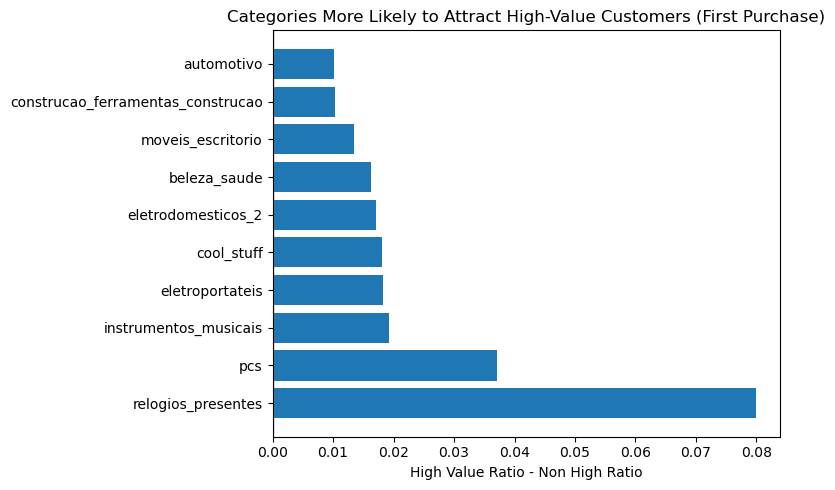

In [119]:
top_diff = pivot_sorted.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_diff.index, top_diff["diff_high_minus_non"])
plt.axvline(0, color="gray", linewidth=1)

plt.title("Categories More Likely to Attract High-Value Customers (First Purchase)")
plt.xlabel("High Value Ratio - Non High Ratio")
plt.tight_layout()
plt.show()

##### 이 카테고리로 첫 구매를 한 고객 중에서
##### High Value 고객 비율이
##### 일반 고객 비율보다 얼마나 더 높은가를 보여주는 그래프 (차이 그래프 -> 바가 클 수록 고가치고객이 고른 편향이 강함)

----
##### 이번에는 고가치고객이 첫구매에서 가장 많이 고른 카테고리를 순서대로 5위까지 뽑아본다

In [120]:
top5_high_volume = (
    first_category_dist
    [first_category_dist["high_value"] == True]
    .sort_values("ratio", ascending=False)
    .head(5)["product_category_name"]
    .tolist()
)

top5_high_volume

['relogios_presentes',
 'beleza_saude',
 'informatica_acessorios',
 'cool_stuff',
 'esporte_lazer']

In [121]:
top5_categories = [
    'relogios_presentes',
    'beleza_saude',
    'informatica_acessorios',
    'cool_stuff',
    'esporte_lazer'
]

In [122]:
first_orders.columns

Index(['customer_unique_id', 'order_id', 'order_purchase_timestamp',
       'product_id', 'product_category_name', 'high_value'],
      dtype='object')

In [125]:
first_orders.columns


Index(['customer_unique_id', 'order_id', 'order_purchase_timestamp',
       'product_id', 'product_category_name', 'high_value'],
      dtype='object')

---
##### 카테고리별 하이와 노말 비율 계산

In [126]:
category_dist = (
    first_orders
    .dropna(subset=["product_category_name"])  # 카테고리 결측 제거(권장)
    .groupby(["high_value", "product_category_name"])
    .size()
    .groupby(level=0, group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name="ratio")
)
category_dist.head()

,high_value,product_category_name,ratio
0,False,agro_industria_e_comercio,0.001464
1,False,alimentos,0.004816
2,False,alimentos_bebidas,0.002334
3,False,artes,0.002139
4,False,artes_e_artesanato,0.000217


In [127]:
#차이 계산
pivot = (
    category_dist
    .pivot(index="product_category_name", columns="high_value", values="ratio")
    .fillna(0)
    .rename(columns={False: "normal", True: "high"})
)

pivot["diff_high_minus_normal"] = pivot["high"] - pivot["normal"]
pivot_sorted = pivot.sort_values("diff_high_minus_normal", ascending=False)

pivot_sorted.head(10)

high_value,normal,high,diff_high_minus_normal
product_category_name,,,
relogios_presentes,0.053759,0.133664,0.079905
pcs,0.000011,0.037141,0.037130
instrumentos_musicais,0.005503,0.024833,0.019330
eletroportateis,0.005526,0.023753,0.018227
cool_stuff,0.036816,0.054848,0.018032
eletrodomesticos_2,0.001487,0.018571,0.017083
beleza_saude,0.089900,0.106241,0.016340
moveis_escritorio,0.012608,0.026128,0.013521
construcao_ferramentas_construcao,0.007150,0.017491,0.010340


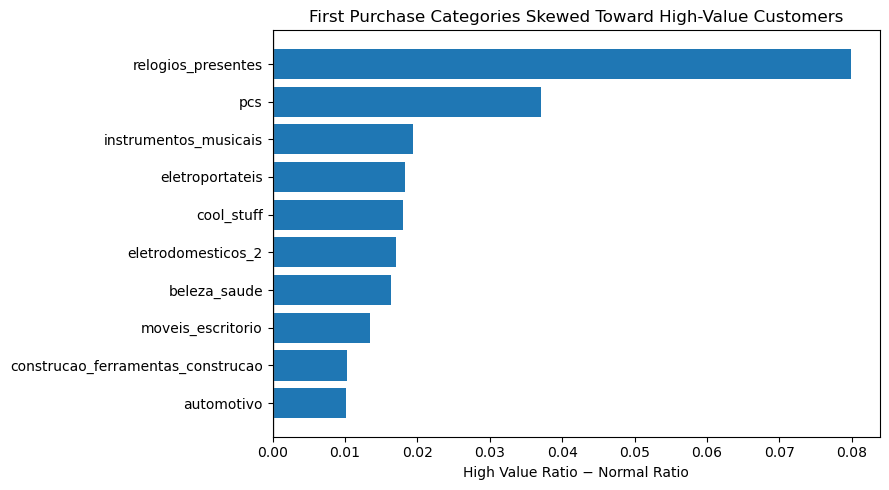

In [128]:
import matplotlib.pyplot as plt

top10 = pivot_sorted.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top10.index, top10["diff_high_minus_normal"])
plt.axvline(0, color="gray", linewidth=1)

plt.xlabel("High Value Ratio − Normal Ratio")
plt.title("First Purchase Categories Skewed Toward High-Value Customers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

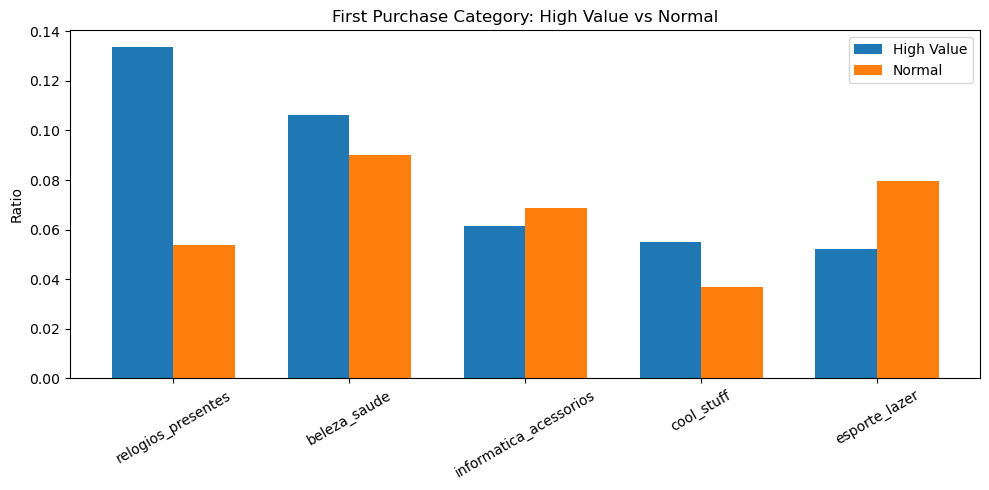

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 카테고리별(첫구매) 분포 비율: High / Normal 각각 내부에서 정규화
category_dist = (
    first_orders
    .dropna(subset=["product_category_name", "high_value"])
    .groupby(["high_value", "product_category_name"])
    .size()
    .groupby(level=0, group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name="ratio")
)

# 2) Wide 형태로 변환 (행=카테고리, 열=high_value)
pivot = (
    category_dist
    .pivot(index="product_category_name", columns="high_value", values="ratio")
    .fillna(0)
    .rename(columns={True: "High Value", False: "Normal"})
)

# 3) High Value가 "가장 많이 고른" 카테고리 Top5 선택 (발표자료 패턴 그대로)
top5_categories = (
    pivot["High Value"]
    .sort_values(ascending=False)
    .head(5)
    .index
)

plot_df = pivot.loc[top5_categories, ["High Value", "Normal"]]

# 4) 그룹드 바 차트 그리기 (High vs Normal)
x = np.arange(len(plot_df.index))  # 카테고리 위치
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, plot_df["High Value"], width, label="High Value")
plt.bar(x + width/2, plot_df["Normal"], width, label="Normal")

plt.title("First Purchase Category: High Value vs Normal")
plt.ylabel("Ratio")
plt.xticks(x, plot_df.index, rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

In [131]:
import numpy as np

# 안전하게 숫자만/결측 제거
df = first_order_prices[["high_value", "price"]].dropna().copy()
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"])

# 그룹별 중앙값
median_by_group = df.groupby("high_value")["price"].median()

median_high = float(median_by_group.loc[True])
median_normal = float(median_by_group.loc[False])

ratio = median_high / median_normal

print("◆ 첫 구매 상품 단가 중앙값 (Median)")
print(f"- High Value 고객 : {median_high:.1f}")
print(f"- Normal 고객     : {median_normal:.1f}")
print(f"→ 약 {ratio:.1f}배 차이")

◆ 첫 구매 상품 단가 중앙값 (Median)
- High Value 고객 : 467.0
- Normal 고객     : 69.9
→ 약 6.7배 차이


/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_1756/2167379810.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


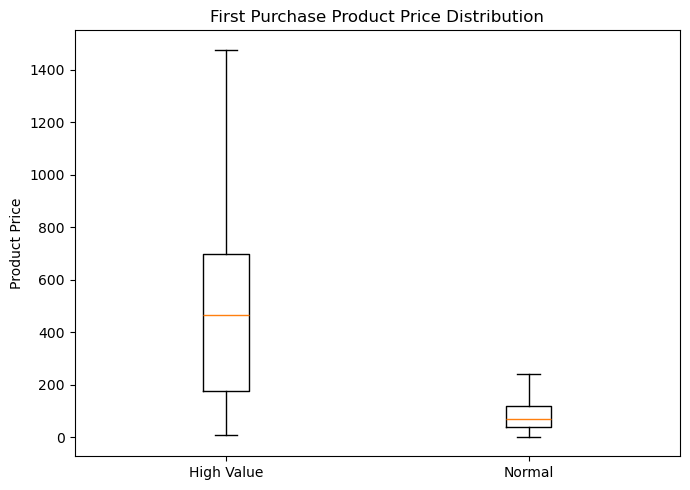

In [132]:
import matplotlib.pyplot as plt

# 사용할 컬럼만 정리
plot_df = (
    first_order_prices
    .loc[:, ["high_value", "price"]]
    .dropna()
)

# 그룹 분리
high_prices = plot_df.loc[plot_df["high_value"] == True, "price"]
normal_prices = plot_df.loc[plot_df["high_value"] == False, "price"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [high_prices, normal_prices],
    labels=["High Value", "Normal"],
    showfliers=False,   # 극단치 숨김 (발표용 핵심)
    vert=True
)

plt.title("First Purchase Product Price Distribution")
plt.ylabel("Product Price")

plt.tight_layout()
plt.show()

In [133]:
# STEP 5-SIM-3. 고객 1%p당 매출 기여도 비교

contribution_df = pd.DataFrame({
    'Group': ['Top 5% Customers', 'All Customers'],
    'Revenue Share (%)': [26.73, 100],
    'Customer Share (%)': [5, 100]
})

contribution_df['Revenue per 1% Customer'] = (
    contribution_df['Revenue Share (%)']
    / contribution_df['Customer Share (%)']
)

contribution_df

,Group,Revenue Share (%),Customer Share (%),Revenue per 1% Customer
0,Top 5% Customers,26.73,5,5.346
1,All Customers,100.00,100,1.000


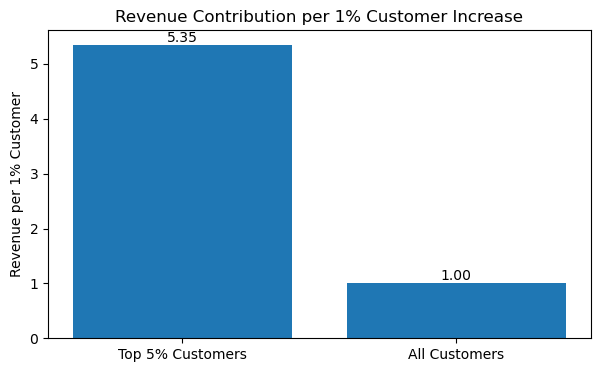

In [134]:
# STEP 5-SIM-VIZ-1. 고객 1%p당 매출 기여도 막대그래프
# - 슬라이드용: 막대 2개만 크게, 값 라벨 표시

import matplotlib.pyplot as plt

df = contribution_df.copy()

plt.figure(figsize=(7, 4))
bars = plt.bar(df['Group'], df['Revenue per 1% Customer'])

plt.title('Revenue Contribution per 1% Customer Increase')
plt.ylabel('Revenue per 1% Customer')

# 막대 위에 값 표시 (발표용 가독성)
for b in bars:
    v = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}', ha='center', va='bottom')

plt.show()

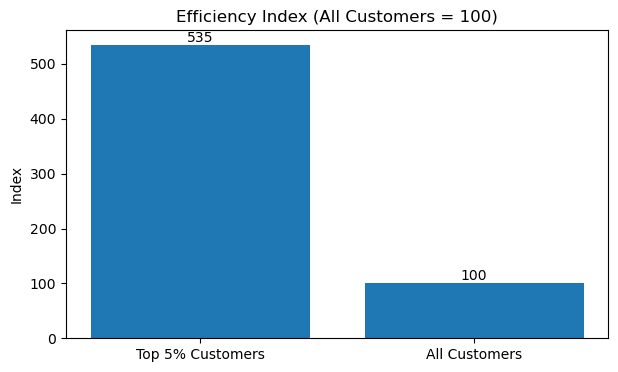

In [135]:
# STEP 5-SIM-VIZ-2. 전체 고객 평균=100으로 지수화 (Index chart)

import matplotlib.pyplot as plt

df = contribution_df.copy()

baseline = df.loc[df['Group'] == 'All Customers', 'Revenue per 1% Customer'].iloc[0]
df['Index (All Customers = 100)'] = (df['Revenue per 1% Customer'] / baseline) * 100

plt.figure(figsize=(7, 4))
bars = plt.bar(df['Group'], df['Index (All Customers = 100)'])

plt.title('Efficiency Index (All Customers = 100)')
plt.ylabel('Index')

for b in bars:
    v = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, v, f'{v:.0f}', ha='center', va='bottom')

plt.show()

본 분석은 고객 수 증가에 따른 매출 효과를
절대 매출 규모가 아닌 ‘효율’ 관점에서 비교하기 위해 수행되었다.

먼저 고객별 LTV를 계산한 후,
전체 고객 중 상위 5%를 고가치 고객(High Value)으로 정의하였다.
이후 전.체 매출에서 각 고객 그룹이 차지하는 매출 비중과
각 그룹의 고객 비중을 비교하여,
고객 비중 1%p당 평균적으로 얼마의 매출을 기여하는지를 계산하였다.


시각화에서는 전체 고객 평균의 매출 기여도를 기준값 100으로 설정하고,
고가치 고객의 상대적인 매출 기여도를 지수(Index) 형태로 표현하였다.

분석 결과,
전체 고객 평균은 고객 비중 1%p당 매출 기여도가 1인 반면,
고가치 고객은 고객 비중 1%p당 약 5.35의 매출 기여도를 보였다.
이는 고가치 고객의 매출 기여 효율이
전체 고객 평균 대비 약 5.35배 높음을 의미한다

📌 STEP 4-EXT-REGION-1

고가치 고객(Top 5%)의 지역(State) 분포 비교

보고 싶은 질문
“고가치 고객은 특정 지역(State)에 더 집중되어 있는가,
아니면 일반 고객과 유사한 분포를 보이는가?”

✅ 사용할 컬럼
	•	고객 구분: segment
	•	‘High Value’
	•	‘Normal’
	•	지역 정보: customer_state
(없으면 지금 데이터프레임 컬럼 다시 확인)

✅ 분석 단위
	•	고객 단위
	•	주문 수 ❌ / 매출 ❌
→ “사람이 어디에 사느냐”만 봄

In [137]:
# STEP R-1. 고객 지역 정보 로드
# - customer_id별 customer_state를 확보

import pandas as pd

customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

# customer_id 기준으로 state만 남기기 (중복 방지)
customers_state = customers[['customer_id', 'customer_state']].drop_duplicates()

customers_state.head()

,customer_id,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,SP
1,18955e83d337fd6b2def6b18a428ac77,SP
2,4e7b3e00288586ebd08712fdd0374a03,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,SP


In [138]:
# customer_id → customer_unique_id + state 매핑
customer_state_map = (
    customers[['customer_id', 'customer_unique_id', 'customer_state']]
    .drop_duplicates()
)

customer_state_map.head()

,customer_id,customer_unique_id,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,SP


In [ ]:
#고가치 고객 테이블과 결합

customer_with_state = (
    customer_ltv
    .merge(
        customer_state_map[['customer_unique_id', 'customer_state']],
        on='customer_unique_id',
        how='left'
    )
)

customer_with_state.head()

,customer_unique_id,ltv,segment,high_value,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,Mid,False,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low,False,SP
2,0000f46a3911fa3c0805444483337064,86.22,Low,False,SC
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,Low,False,PA
4,0004aac84e0df4da2b147fca70cf8255,196.89,Mid,False,SP


In [ ]:
customer_with_state['customer_state'].isna().mean()

np.float64(0.0)

#### 지역별 고객 분포 비율 계산 

In [ ]:
high_value_count_by_state = (
    customer_region
    .loc[customer_region["high_value"] == True]
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .reset_index(name="high_value_customer_count")
    .sort_values("high_value_customer_count", ascending=False)
)

high_value_count_by_state.head(10)

,customer_state,high_value_customer_count
25,SP,1598
18,RJ,598
10,MG,528
17,PR,237
22,RS,235
4,BA,205
23,SC,187
8,GO,114
15,PE,109
6,DF,107


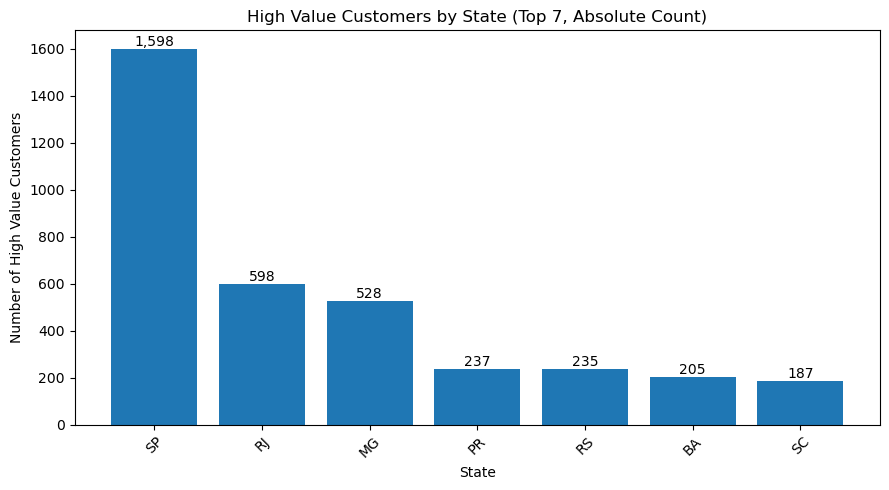

In [ ]:
import matplotlib.pyplot as plt

top_n = 7
plot_df = high_value_count_by_state.head(top_n)

plt.figure(figsize=(9, 5))
plt.bar(
    plot_df["customer_state"],
    plot_df["high_value_customer_count"]
)

plt.title("High Value Customers by State (Top 7, Absolute Count)")
plt.xlabel("State")
plt.ylabel("Number of High Value Customers")

# 값 라벨 표시 (발표용 추천)
for i, v in enumerate(plot_df["high_value_customer_count"]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

✅ 마케팅 관점에서 써야 할 정의

고가치 고객이 ‘수적으로 많이 존재하는 지역’을
타겟 마케팅 후보 지역으로 식별한다
1️⃣ 지역별 고가치 고객 수 (절대 수)
→ “어디에 고가치 고객 풀이 큰가?”

2️⃣ (보조) 지역별 전체 고객 수
→ “이게 단순히 인구 많은 효과인지 체크